## Download and process ONC AZFP data

This notebook demonstrates how to request, download, calibrate, and grid raw Acoustic Zooplankton and Fish Profiler (AZFP) data from Ocean Networks Canada (ONC) using the ONC Python API and Echopype.

An ONC account and API token are required to download the data. Your token is available from your [ONC account profile](https://data.oceannetworks.ca/DataSearch). Interested users can find additional examples in the [ONC echosounder examples repository](https://github.com/slonimer/onc-echosounder-examples)!

### Import packages and configure the download

In [ ]:
from pathlib import Path
import echopype as ep
from onc import ONC

download_dir = Path("example_data/ONC").resolve()
download_dir.mkdir(parents=True, exist_ok=True)

onc = ONC(
    token="your_api_token_here",
    outPath=download_dir,
)

### Download the data

Define the data-product request filters. Here, we request one hour of raw data from AZFP device `ASLAZFP55196`. The request covers 7 July 2024 from 00:00 to 01:00 UTC.

In [2]:
filters = {
    "deviceCode": "ASLAZFP55196",
    "dataProductCode": "AAPTS",
    "extension": "01a",
    "dateFrom": "2024-07-07T00:00:00.000Z",
    "dateTo": "2024-07-07T01:00:00.000Z",
    "dpo_aslBinarySource": 0,
}

request = onc.requestDataProduct(filters)

print("Request ID:", request["dpRequestId"])
print("Estimated size:", request["estimatedFileSize"])

Request Id: 46287610
Estimated File Size: 17 MB
Estimated Processing Time: 10 s
Request ID: 46287610
Estimated size: 17 MB


Submit the request and wait for ONC to generate the data-product files.

In [3]:
run = onc.runDataProduct(
    request["dpRequestId"],
    waitComplete=True,
)

print("Files generated:", run["fileCount"])

To cancel the running data product, run 'onc.cancelDataProduct(46287610)'

   queued
   data product running.........
   3 files generated for this data product
   complete
Files generated: 3


Download the generated files to the local data directory.

In [4]:
downloaded_files = onc.downloadDataProduct(run["runIds"][0])



   Search complete, waiting on the file system to synchronize (ASLAZFP55196_20240707T000000.578Z_20240707T005955.539Z.01a)...........................................
   Skipping "ASLAZFP55196_20240707T000000.578Z_20240707T005955.539Z.01a": File already exists.
   Skipping "ASLAZFP55196_20240707T000000.578_20240707T005955.539Z.xml": File already exists.
   Skipping "readMe.txt": File already exists.
   Skipping "ASLAZFP55196_20240707T000000Z_20240707T005955Z_01A_META.xml": File already exists.


### Open the AZFP file

Identify the downloaded AZFP binary file and its corresponding instrument configuration file. The ONC metadata XML file is excluded because Echopype requires the AZFP instrument configuration XML.

In [5]:
raw_files = list(download_dir.glob("*.01a"))
xml_files = [
    path
    for path in download_dir.glob("*.xml")
    if "_META" not in path.name.upper()
]

if len(raw_files) != 1:
    raise ValueError(f"Expected one .01a file, found {len(raw_files)}.")

if len(xml_files) != 1:
    raise ValueError(
        f"Expected one AZFP configuration XML file, found {len(xml_files)}."
    )

raw_file = raw_files[0]
xml_file = xml_files[0]

print("Raw file:", raw_file.name)
print("Configuration file:", xml_file.name)

Raw file: ASLAZFP55196_20240707T000000.578Z_20240707T005955.539Z.01a
Configuration file: ASLAZFP55196_20240707T000000.578_20240707T005955.539Z.xml


Open the raw AZFP file using its associated instrument configuration XML.

In [6]:
echodata = ep.open_raw(
    raw_file=raw_file,
    sonar_model="AZFP",
    xml_path=xml_file,
)

echodata

<EchoData: standardized raw data from Internal Memory>
Top-level: contains metadata about the SONAR-netCDF4 file format.
├── Environment: contains information relevant to acoustic propagation through water.
├── Platform: contains information about the platform on which the sonar is installed.
├── Provenance: contains metadata about how the SONAR-netCDF4 version of the data were obtained.
├── Sonar: contains sonar system metadata and sonar beam groups.
│   └── Beam_group1: contains backscatter power (uncalibrated) and other beam or channel-specific data.
└── Vendor_specific: contains vendor-specific information about the sonar and the data.

### Inspect instrument and environmental metadata

The nominal frequency identifies the frequency associated with each acoustic channel. AZFP instruments also record internal temperature, whereas salinity and deployment pressure generally need to be obtained from accompanying deployment or environmental metadata.

In [7]:
frequency_nominal = echodata["Sonar/Beam_group1"]["frequency_nominal"]
frequency_nominal

<xarray.DataArray 'frequency_nominal' (channel: 3)> Size: 24B
array([ 38000., 120000., 200000.])
Coordinates:
  * channel  (channel) object 24B '55196-38-1' '55196-120-2' '55196-200-3'
Attributes:
    units:          Hz
    long_name:      Transducer frequency
    valid_min:      0.0
    standard_name:  sound_frequency

In [8]:
echodata["Environment"]

<xarray.Dataset> Size: 12kB
Dimensions:                 (channel: 3, time1: 720)
Coordinates:
  * channel                 (channel) object 24B '55196-38-1' ... '55196-200-3'
  * time1                   (time1) datetime64[ns] 6kB 2024-07-07 ... 2024-07...
Data variables:
    absorption_indicative   (channel) float64 24B nan nan nan
    sound_speed_indicative  float64 8B nan
    frequency_nominal       (channel) float64 24B 3.8e+04 1.2e+05 2e+05
    temperature             (time1) float64 6kB 10.09 10.09 10.09 ... 10.21 10.2

In [9]:
echodata["Platform"]

<xarray.Dataset> Size: 35kB
Dimensions:              (time1: 1, time2: 720, channel: 3)
Coordinates:
  * time1                (time1) datetime64[ns] 8B 2024-07-07
  * time2                (time2) datetime64[ns] 6kB 2024-07-07 ... 2024-07-07...
  * channel              (channel) object 24B '55196-38-1' ... '55196-200-3'
Data variables: (12/21)
    latitude             (time1) float64 8B nan
    longitude            (time1) float64 8B nan
    pitch                (time2) float64 6kB nan nan nan nan ... nan nan nan nan
    roll                 (time2) float64 6kB nan nan nan nan ... nan nan nan nan
    vertical_offset      (time2) float64 6kB nan nan nan nan ... nan nan nan nan
    water_level          float64 8B nan
    ...                   ...
    MRU_rotation_y       float64 8B nan
    MRU_rotation_z       float64 8B nan
    position_offset_x    float64 8B nan
    position_offset_y    float64 8B nan
    position_offset_z    float64 8B nan
    frequency_nominal    (channel) float64 24B 3.8e+04 1.2e+05 2e+05
Attributes:
    platform_name:       
    platform_type:       
    platform_code_ICES:

### Calibrate volume backscattering strength

For this example, salinity and pressure are supplied explicitly, while Echopype uses the temperature stored in the AZFP data. Here, pressure is approximated from a transducer depth of 165 m.

In [10]:
transducer_depth = 165.0  # m

env_params = {
    "salinity": 32,               # PSU; to verify
    "pressure": transducer_depth, # dbar; approximate value at 165 m depth
}

ds_Sv = ep.calibrate.compute_Sv(
    echodata,
    env_params=env_params,
).set_coords("echo_range")

ds_Sv

<xarray.Dataset> Size: 55MB
Dimensions:                (channel: 3, ping_time: 720, range_sample: 1580,
                            filenames: 1)
Coordinates:
  * channel                (channel) object 24B '55196-38-1' ... '55196-200-3'
  * ping_time              (ping_time) datetime64[ns] 6kB 2024-07-07 ... 2024...
  * range_sample           (range_sample) int64 13kB 0 1 2 3 ... 1577 1578 1579
    echo_range             (channel, ping_time, range_sample) float64 27MB 4....
  * filenames              (filenames) int64 8B 0
Data variables: (12/17)
    Sv                     (channel, ping_time, range_sample) float64 27MB -6...
    frequency_nominal      (channel) float64 24B 3.8e+04 1.2e+05 2e+05
    sound_speed            (ping_time) float64 6kB 1.489e+03 ... 1.49e+03
    sound_absorption       (ping_time, channel) float64 17kB 0.007264 ... 0.0...
    temperature            (ping_time) float64 6kB 10.09 10.09 ... 10.21 10.2
    salinity               int64 8B 32
    ...                     ...
    TVR                    (channel) float64 24B 174.8 167.7 172.2
    VTX0                   (channel) float64 24B 65.1 149.9 95.5
    equivalent_beam_angle  (channel) float64 24B 0.02409 0.01071 0.01356
    Sv_offset              (channel) float64 24B 0.9 1.1 1.1
    source_filenames       (filenames) <U142 568B 'C:\\Users\\lloyd\\Desktop\...
    water_level            float64 8B nan
Attributes:
    processing_software_name:     echopype
    processing_software_version:  0.11.2.dev183+g02b009a05
    processing_time:              2026-07-23T18:47:29+00:00
    processing_function:          calibrate.compute_Sv

Inspect the environmental parameters and derived quantities used during calibration.

In [11]:
calibration_environment = [
    name
    for name in [
        "temperature",
        "salinity",
        "pressure",
        "sound_speed",
        "sound_absorption",
    ]
    if name in ds_Sv
]

ds_Sv[calibration_environment]

<xarray.Dataset> Size: 35kB
Dimensions:           (ping_time: 720, channel: 3)
Coordinates:
  * ping_time         (ping_time) datetime64[ns] 6kB 2024-07-07 ... 2024-07-0...
  * channel           (channel) object 24B '55196-38-1' ... '55196-200-3'
Data variables:
    temperature       (ping_time) float64 6kB 10.09 10.09 10.09 ... 10.21 10.2
    salinity          int64 8B 32
    pressure          float64 8B 165.0
    sound_speed       (ping_time) float64 6kB 1.489e+03 1.489e+03 ... 1.49e+03
    sound_absorption  (ping_time, channel) float64 17kB 0.007264 ... 0.05045
Attributes:
    processing_software_name:     echopype
    processing_software_version:  0.11.2.dev183+g02b009a05
    processing_time:              2026-07-23T18:47:29+00:00
    processing_function:          calibrate.compute_Sv

### Visualize calibrated data by range

`echo_range` represents distance from the transducer along the acoustic beam. At this stage, the vertical axis is relative to the transducer rather than to the sea surface.

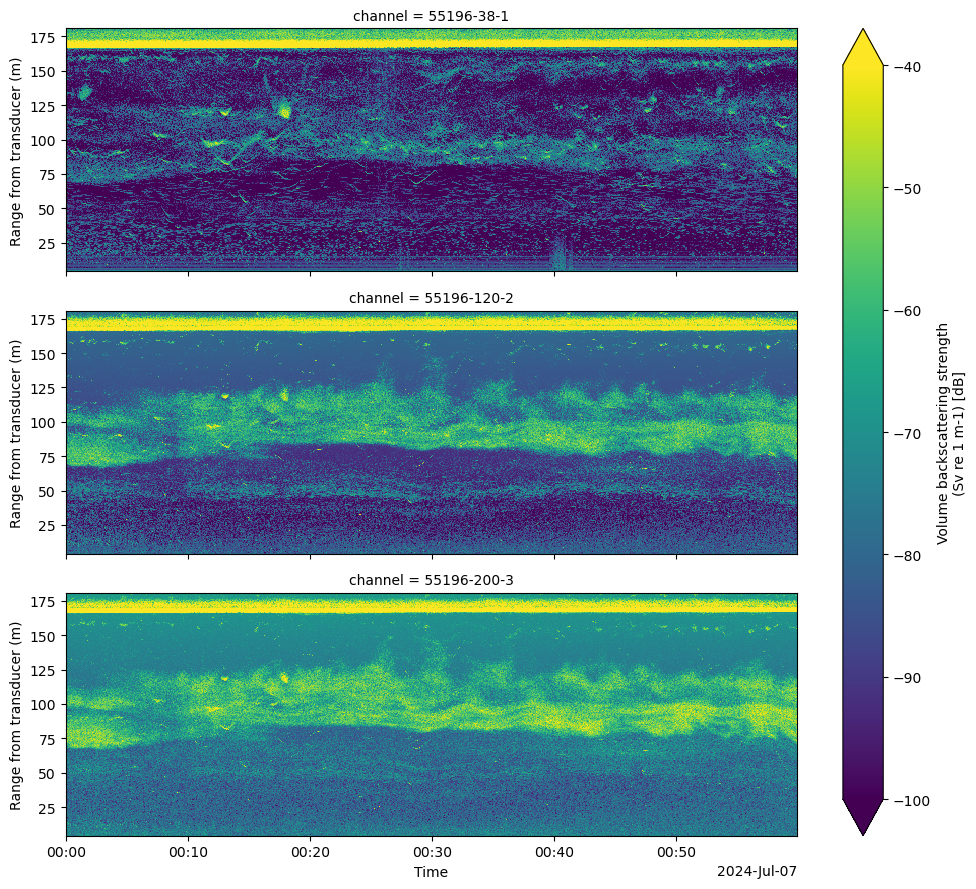

In [12]:
range_plot = ds_Sv["Sv"].plot.pcolormesh(
    x="ping_time",
    y="echo_range",
    col="channel",
    col_wrap=1,
    yincrease=True,
    cmap="viridis",
    vmin=-100,
    vmax=-40,
    size=3,
    aspect=3,
)

range_plot.set_xlabels("Time")
range_plot.set_ylabels("Range from transducer (m)")

### Convert range to depth below the sea surface

This AZFP is mounted on the seafloor and points upward. The `depth_offset` below is the depth of the transducer itself.

In [13]:
ds_Sv_depth = ep.consolidate.add_depth(
    ds_Sv,
    depth_offset=transducer_depth,
    downward=False,
).set_coords("depth")

ds_Sv_depth["depth"]

<xarray.DataArray 'depth' (channel: 3, ping_time: 720, range_sample: 1580)> Size: 27MB
array([[[160.56974751, 160.45806047, 160.34637344, ..., -15.56071068,
         -15.67239772, -15.78408476],
        [160.56978229, 160.45809613, 160.34640997, ..., -15.55929332,
         -15.67097948, -15.78266564],
        [160.5697649 , 160.4580783 , 160.3463917 , ..., -15.56000202,
         -15.67168862, -15.78337522],
        ...,
        [160.56854967, 160.45683243, 160.3451152 , ..., -15.60953038,
         -15.72124761, -15.83296485],
        [160.56853233, 160.45681466, 160.34509699, ..., -15.61023678,
         -15.72195445, -15.83367212],
        [160.568567  , 160.4568502 , 160.3451334 , ..., -15.60882394,
         -15.72054074, -15.83225754]],

       [[160.75589257, 160.64420554, 160.5325185 , ..., -15.37456562,
         -15.48625266, -15.5979397 ],
        [160.75592589, 160.64423973, 160.53255357, ..., -15.37314972,
         -15.48483588, -15.59652204],
        [160.75590923, 160.64422263, 160.53253603, ..., -15.37385769,
         -15.48554429, -15.59723089],
...
        [160.75474506, 160.64302782, 160.53131059, ..., -15.42333498,
         -15.53505222, -15.64676945],
        [160.75472846, 160.64301078, 160.53129311, ..., -15.42404066,
         -15.53575833, -15.647476  ],
        [160.75476166, 160.64304487, 160.53132807, ..., -15.42262928,
         -15.53434608, -15.64606287]],

       [[160.75589257, 160.64420554, 160.5325185 , ..., -15.37456562,
         -15.48625266, -15.5979397 ],
        [160.75592589, 160.64423973, 160.53255357, ..., -15.37314972,
         -15.48483588, -15.59652204],
        [160.75590923, 160.64422263, 160.53253603, ..., -15.37385769,
         -15.48554429, -15.59723089],
        ...,
        [160.75474506, 160.64302782, 160.53131059, ..., -15.42333498,
         -15.53505222, -15.64676945],
        [160.75472846, 160.64301078, 160.53129311, ..., -15.42404066,
         -15.53575833, -15.647476  ],
        [160.75476166, 160.64304487, 160.53132807, ..., -15.42262928,
         -15.53434608, -15.64606287]]], shape=(3, 720, 1580))
Coordinates:
  * channel       (channel) object 24B '55196-38-1' '55196-120-2' '55196-200-3'
  * ping_time     (ping_time) datetime64[ns] 6kB 2024-07-07 ... 2024-07-07T00...
  * range_sample  (range_sample) int64 13kB 0 1 2 3 4 ... 1576 1577 1578 1579
    echo_range    (channel, ping_time, range_sample) float64 27MB 4.43 ... 180.6
    depth         (channel, ping_time, range_sample) float64 27MB 160.6 ... -...
Attributes:
    long_name:  Range distance
    units:      m
    history:    2026-07-23 18:47:33.108119+00:00. `depth` calculated using: S...

Before gridding, `depth` can vary across channel, time, and range sample, so it is a multidimensional auxiliary coordinate rather than a one-dimensional dimension. Explicit `pcolormesh` plotting allows xarray to use this physical coordinate.

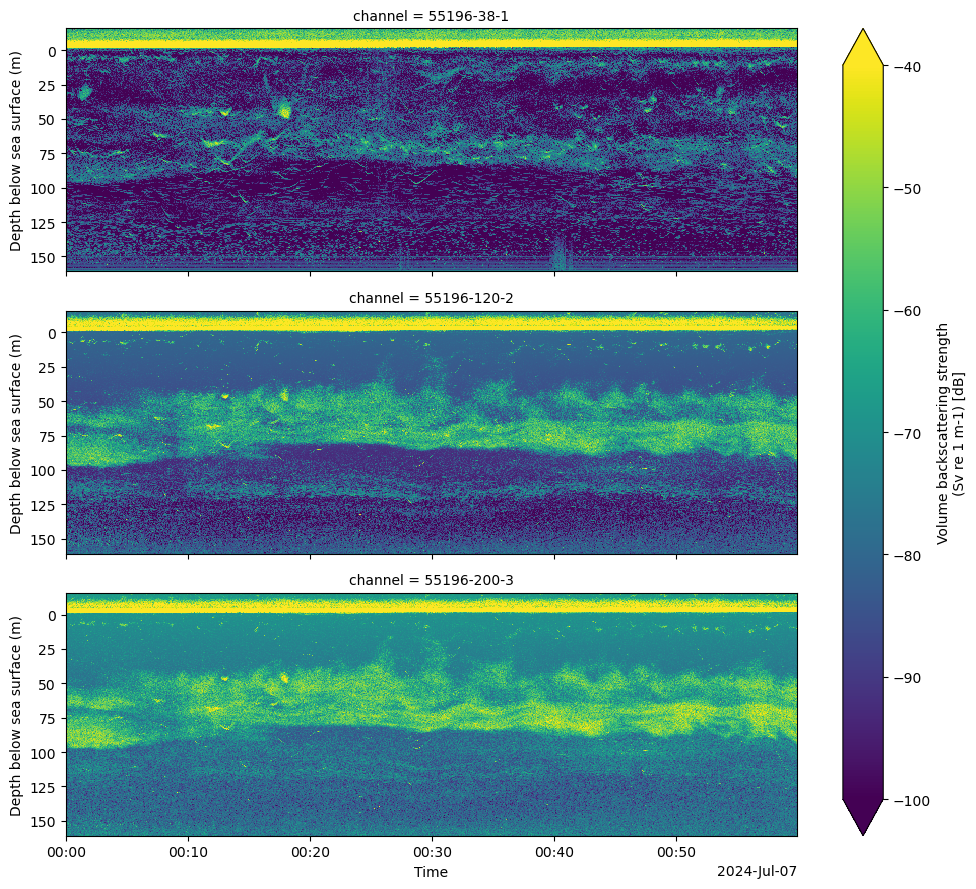

In [14]:
depth_plot = ds_Sv_depth["Sv"].plot.pcolormesh(
    x="ping_time",
    y="depth",
    col="channel",
    col_wrap=1,
    yincrease=False,
    cmap="viridis",
    vmin=-100,
    vmax=-40,
    size=3,
    aspect=3,
)

depth_plot.set_xlabels("Time")
depth_plot.set_ylabels("Depth below sea surface (m)")

### Compute MVBS on a depth grid

Compute mean volume backscattering strength (MVBS) using 0.5 m absolute-depth bins and 30 s time bins. A distinct object name emphasizes that this product is gridded by depth, not by range from the transducer.

In [15]:
ds_MVBS_depth = ep.commongrid.compute_MVBS(
    ds_Sv_depth,
    range_var="depth",
    range_bin="0.5m",
    ping_time_bin="30s",
)

ds_MVBS_depth

<xarray.Dataset> Size: 931kB
Dimensions:            (channel: 3, ping_time: 120, depth: 322)
Coordinates:
  * channel            (channel) object 24B '55196-120-2' ... '55196-38-1'
  * ping_time          (ping_time) datetime64[ns] 960B 2024-07-07 ... 2024-07...
  * depth              (depth) float64 3kB 0.0 0.5 1.0 1.5 ... 159.5 160.0 160.5
Data variables:
    Sv                 (channel, ping_time, depth) float64 927kB -79.98 ... -...
    frequency_nominal  (channel) float64 24B 1.2e+05 2e+05 3.8e+04
Attributes:
    processing_software_name:     echopype
    processing_software_version:  0.11.2.dev183+g02b009a05
    processing_time:              2026-07-23T18:47:35+00:00
    processing_function:          commongrid.compute_MVBS

Verify the dimensions before plotting the depth-gridded MVBS product.

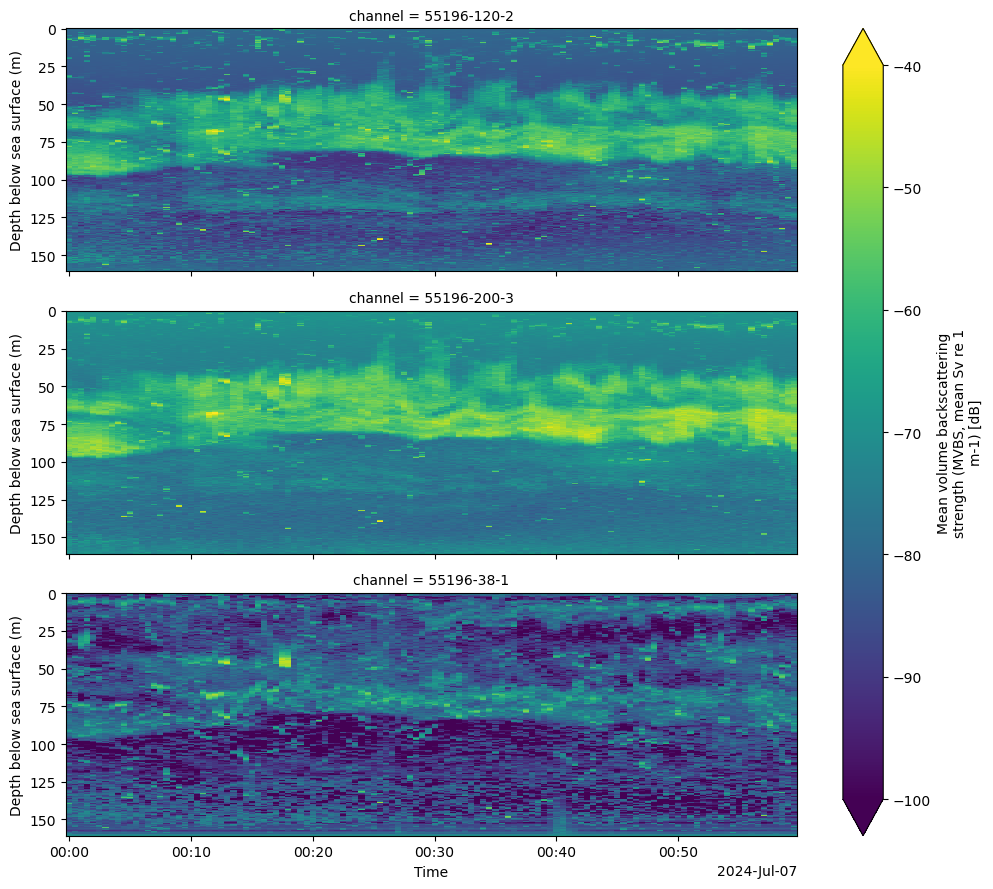

In [16]:
mvbs_plot = ds_MVBS_depth["Sv"].plot.pcolormesh(
    x="ping_time",
    y="depth",
    col="channel",
    col_wrap=1,
    yincrease=False,
    cmap="viridis",
    vmin=-100,
    vmax=-40,
    size=3,
    aspect=3,
)

mvbs_plot.set_xlabels("Time")
mvbs_plot.set_ylabels("Depth below sea surface (m)")

### Verify channel and frequency mapping

Compare the channel-to-frequency mapping before and after gridding. Each channel must remain associated with its original nominal frequency.

In [17]:
print("Input Sv:")
for channel, frequency in zip(
    ds_Sv_depth["channel"].values,
    ds_Sv_depth["frequency_nominal"].values,
):
    print(channel, frequency)

print("\nDepth-gridded MVBS:")
for channel, frequency in zip(
    ds_MVBS_depth["channel"].values,
    ds_MVBS_depth["frequency_nominal"].values,
):
    print(channel, frequency)

Input Sv:
55196-38-1 38000.0
55196-120-2 120000.0
55196-200-3 200000.0

Depth-gridded MVBS:
55196-120-2 120000.0
55196-200-3 200000.0
55196-38-1 38000.0


End of notebook

In [18]:
from datetime import datetime, timezone
from importlib.metadata import version

print(f"Executed: {datetime.now(timezone.utc):%Y-%m-%d %H:%M:%S UTC}")
print(f"echopype: {ep.__version__}")

for package in ["xarray", "numpy", "matplotlib", "onc"]:
    print(f"{package}: {version(package)}")

Executed: 2026-07-23 18:47:36 UTC
echopype: 0.11.2.dev183+g02b009a05
xarray: 2026.4.0
numpy: 2.4.4
matplotlib: 3.10.9
onc: 2.6.0
